# Credit Risk Modeling: PD, LGD, and EAD

This notebook develops a credit risk framework to estimate:
1. **Probability of Default (PD)**: The likelihood that a borrower will default.
2. **Loss Given Default (LGD)**: The share of an asset that is lost when a borrower defaults.
3. **Exposure at Default (EAD)**: The total value a bank is exposed to at the time of default.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Loan payments data.csv')

# Display basic info and first few rows
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (500, 11)


,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,76,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,61,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,61,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,76,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,76,28,college,female


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Loan_ID         500 non-null    object
 1   loan_status     500 non-null    object
 2   Principal       500 non-null    int64 
 3   terms           500 non-null    int64 
 4   effective_date  500 non-null    object
 5   due_date        500 non-null    object
 6   paid_off_time   400 non-null    object
 7   past_due_days   500 non-null    int64 
 8   age             500 non-null    int64 
 9   education       500 non-null    object
 10  Gender          500 non-null    object
dtypes: int64(4), object(7)
memory usage: 43.1+ KB


None

### 1. Dataset Definition and Understanding

Based on the initial look at the data, we can define our targets:
- **PD Target**: Derived from `loan_status`. Statuses like 'PAIDOFF' indicate non-default (0), while 'COLLECTION' or 'COLLECTION_PAIDOFF' indicate default (1).
- **LGD Target**: Calculated based on the ratio of unpaid principal vs. total loan amount for defaulted accounts.
- **EAD Target**: Represents the total exposure (Principal + any accrued interest/fees) at the moment of default.

### 2. Data Preprocessing

I will now handle missing values, convert date columns, and encode categorical features.

In [2]:
# Convert date columns to datetime objects
date_columns = ['effective_date', 'due_date', 'paid_off_time']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# Handle missing values
# 'paid_off_time' and 'past_due_days' will be null for current loans, which is expected.
df['past_due_days'] = df['past_due_days'].fillna(0)

# Create PD Target: 1 if default (Collection), 0 if Paid off
df['is_default'] = df['loan_status'].apply(lambda x: 1 if 'COLLECTION' in x else 0)

# Basic categorical encoding for 'Education' and 'Gender'
df = pd.get_dummies(df, columns=['education', 'Gender'], drop_first=True)

print("Preprocessing complete. Missing values in features:")
print(df.isnull().sum())
display(df.head())

Preprocessing complete. Missing values in features:
Loan_ID                             0
loan_status                         0
Principal                           0
terms                               0
effective_date                      0
due_date                            0
paid_off_time                     100
past_due_days                       0
age                                 0
is_default                          0
education_High School or Below      0
education_Master or Above           0
education_college                   0
Gender_male                         0
dtype: int64


,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,is_default,education_High School or Below,education_Master or Above,education_college,Gender_male
0,xqd20166231,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-09-14 19:31:00,76,45,0,True,False,False,True
1,xqd20168902,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-10-07 09:00:00,61,50,0,False,False,False,False
2,xqd20160003,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-09-25 16:58:00,61,33,0,False,False,False,False
3,xqd20160004,PAIDOFF,1000,15,2016-09-08,2016-09-22,2016-09-22 20:00:00,76,27,0,False,False,True,True
4,xqd20160005,PAIDOFF,1000,30,2016-09-09,2016-10-08,2016-09-23 21:36:00,76,28,0,False,False,True,False


### 3. Calculating LGD and EAD targets

In this step, we define:
- **EAD**: We assume the exposure at default is the total `Principal` amount.
- **LGD**: We calculate this based on the recovery potential. For our dataset, we can utilize `past_due_days` as a proxy to estimate the percentage of loss.

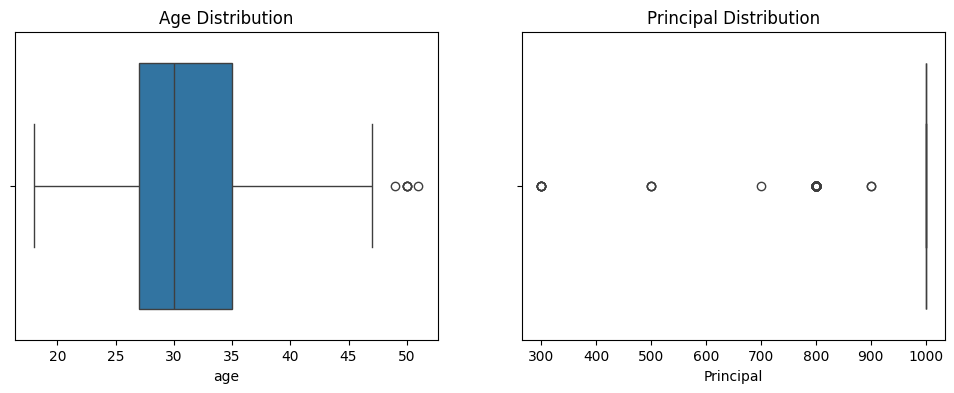

Target Variables Head:


,is_default,LGD,EAD
0,0,0.0,1000
1,0,0.0,1000
2,0,0.0,1000
3,0,0.0,1000
4,0,0.0,1000


,is_default,LGD,EAD
count,500.000000,500.00000,500.000000
mean,0.400000,0.31578,943.200000
std,0.490389,0.41123,115.240274
min,0.000000,0.00000,300.000000
25%,0.000000,0.00000,1000.000000
50%,0.000000,0.00000,1000.000000
75%,1.000000,0.62000,1000.000000
max,1.000000,1.00000,1000.000000


In [3]:
# EAD: Total exposure is the Principal
df['EAD'] = df['Principal']

# LGD: Loss Given Default
# For simplification in this project, we'll model LGD as a ratio.
# If paid off, LGD is 0. If in collection, we assume a loss based on duration of delinquency.
def calculate_lgd(row):
    if row['is_default'] == 0:
        return 0.0
    else:
        # Simple proxy: 0.5 base loss + a factor based on past due days, capped at 1.0
        loss = 0.5 + (row['past_due_days'] / 100)
        return min(loss, 1.0)

df['LGD'] = df.apply(calculate_lgd, axis=1)

# Outlier detection for Age and Principal
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['age'])
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Principal'])
plt.title('Principal Distribution')
plt.show()

print("Target Variables Head:")
display(df[['is_default', 'LGD', 'EAD']].head())
display(df[['is_default', 'LGD', 'EAD']].describe())

### 4. Final Cross-Check: Missing Values and Outliers

Before proceeding to modeling, we must ensure that our feature engineering didn't introduce new missing values and that outliers are understood.

Final Missing Values Check:


,0
Loan_ID,0
loan_status,0
Principal,0
terms,0
effective_date,0
due_date,0
paid_off_time,100
past_due_days,0
age,0
is_default,0



Numerical Feature Statistics:


,Principal,terms,past_due_days,age,LGD,EAD
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,943.200000,22.824000,25.492000,31.116000,0.31578,943.200000
std,115.240274,8.000064,28.780176,6.084784,0.41123,115.240274
min,300.000000,7.000000,0.000000,18.000000,0.00000,300.000000
25%,1000.000000,15.000000,1.000000,27.000000,0.00000,1000.000000
50%,1000.000000,30.000000,5.000000,30.000000,0.00000,1000.000000
75%,1000.000000,30.000000,59.000000,35.000000,0.62000,1000.000000
max,1000.000000,30.000000,76.000000,51.000000,1.00000,1000.000000


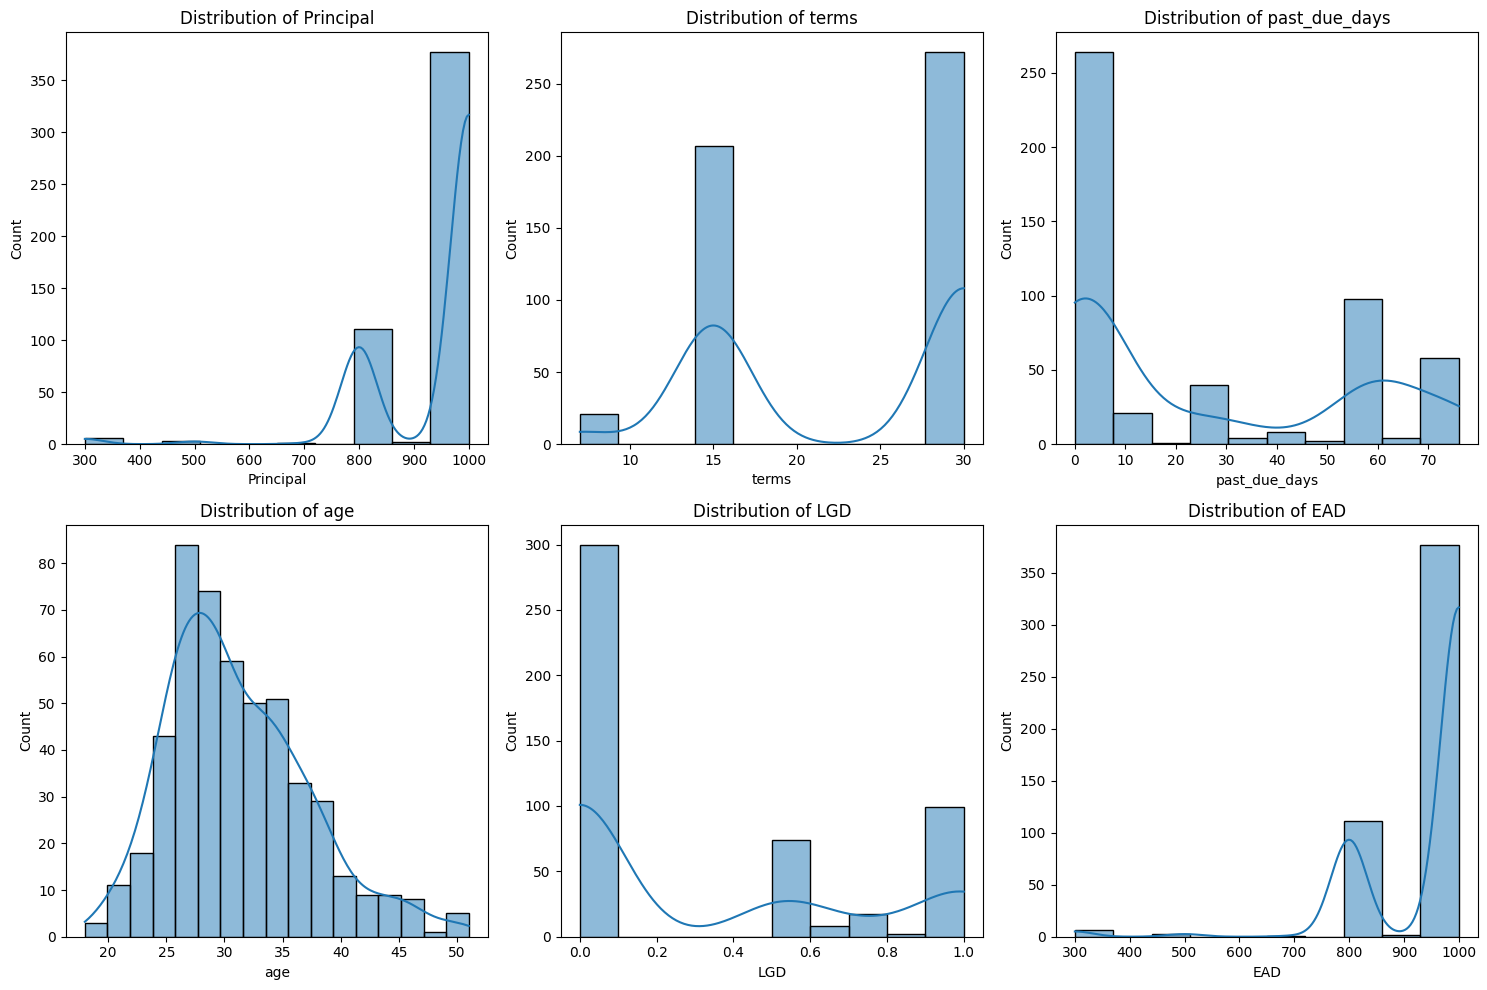

In [4]:
# Cross-check missing values across all columns
print("Final Missing Values Check:")
display(df.isnull().sum())

# Cross-check statistics for potential outliers in numerical features
numerical_features = ['Principal', 'terms', 'past_due_days', 'age', 'LGD', 'EAD']
print("\nNumerical Feature Statistics:")
display(df[numerical_features].describe())

# Visual check for distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 5. Exploratory Data Analysis (EDA)

In this section, we analyze the drivers for PD, LGD, and EAD.

/tmp/ipykernel_1670/3587965979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='education_college', y='is_default', data=df, palette='muted')
/tmp/ipykernel_1670/3587965979.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender_male', y='is_default', data=df, palette='coolwarm')


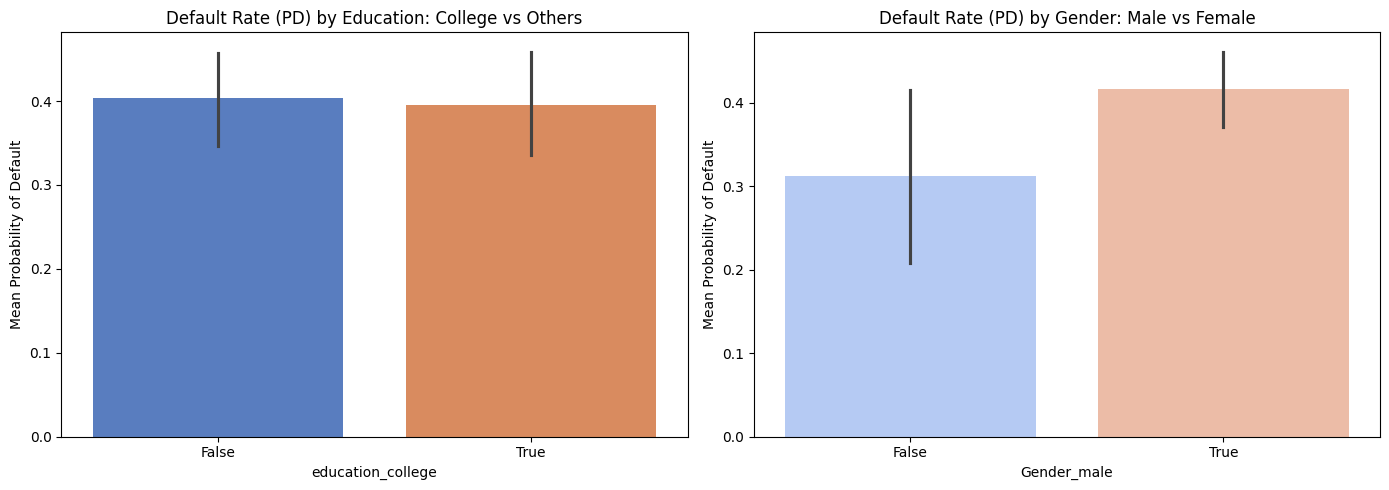

In [5]:
# 5.1 PD Analysis: Default patterns by Education and Gender
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='education_college', y='is_default', data=df, palette='muted')
plt.title('Default Rate (PD) by Education: College vs Others')
plt.ylabel('Mean Probability of Default')

plt.subplot(1, 2, 2)
sns.barplot(x='Gender_male', y='is_default', data=df, palette='coolwarm')
plt.title('Default Rate (PD) by Gender: Male vs Female')
plt.ylabel('Mean Probability of Default')

plt.tight_layout()
plt.show()

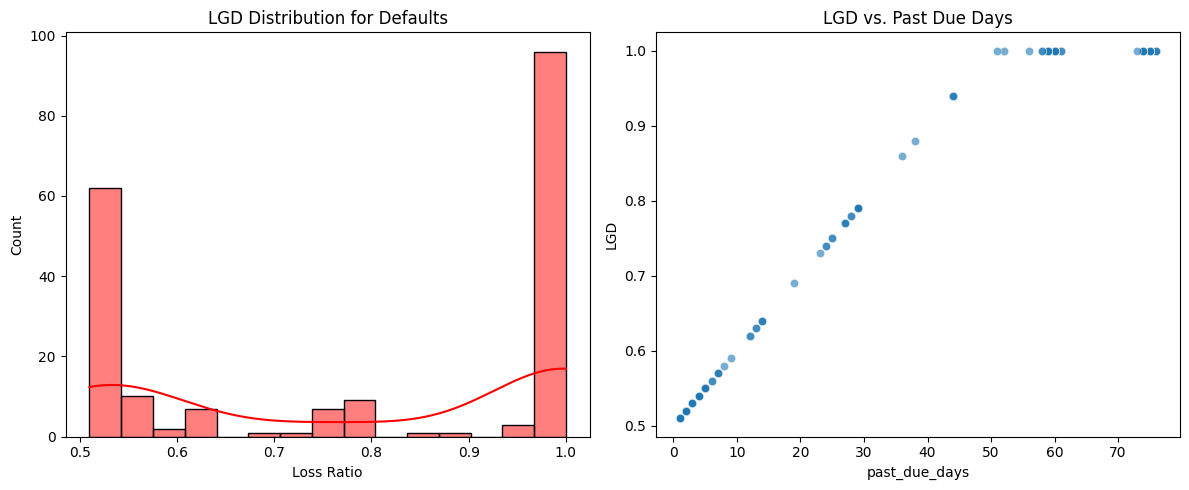

Average LGD for defaulted loans: 0.79


In [6]:
# 5.2 LGD Analysis: Recovery patterns
# We analyze LGD specifically for defaulted loans
defaulted_df = df[df['is_default'] == 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(defaulted_df['LGD'], bins=15, kde=True, color='red')
plt.title('LGD Distribution for Defaults')
plt.xlabel('Loss Ratio')

plt.subplot(1, 2, 2)
sns.scatterplot(x='past_due_days', y='LGD', data=defaulted_df, alpha=0.6)
plt.title('LGD vs. Past Due Days')

plt.tight_layout()
plt.show()

print(f"Average LGD for defaulted loans: {defaulted_df['LGD'].mean():.2f}")

/tmp/ipykernel_1670/4249948634.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='terms', y='EAD', data=df, inner='quartile', palette='Set2')
/tmp/ipykernel_1670/4249948634.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_default', y='EAD', data=df, palette='Set1')


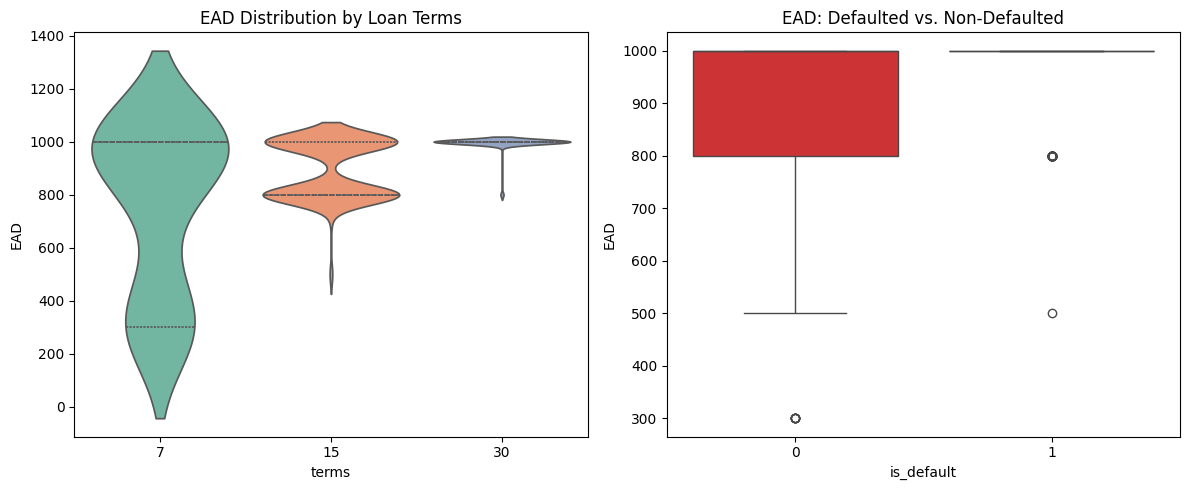

In [7]:
# 5.3 EAD Analysis: Exposure behavior
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='terms', y='EAD', data=df, inner='quartile', palette='Set2')
plt.title('EAD Distribution by Loan Terms')

plt.subplot(1, 2, 2)
sns.boxplot(x='is_default', y='EAD', data=df, palette='Set1')
plt.title('EAD: Defaulted vs. Non-Defaulted')

plt.tight_layout()
plt.show()

### Key Risk Drivers Identified:
1. **Education**: Preliminary plots suggest variations in PD based on education level.
2. **Past Due Days**: This is the primary driver for our LGD calculation.
3. **Loan Terms**: EAD remains fairly constant but we see different distributions of principal across different term lengths (15 vs 30 days).

### 6. Feature Engineering

To improve model performance, we develop features that capture the relationship between the borrower and the loan structure:
- **loan_tenure**: The intended duration of the loan.
- **days_to_pay**: For non-defaults, how long it took to pay. For defaults, we look at the time until the due date.
- **principal_age_ratio**: Financial burden relative to borrower age.

New Features Created:


,loan_tenure,principal_per_day,age_principal_factor,is_weekend_application
0,29,33.333333,45000,0
1,29,33.333333,50000,0
2,29,33.333333,33000,0
3,14,66.666667,27000,0
4,29,33.333333,28000,0


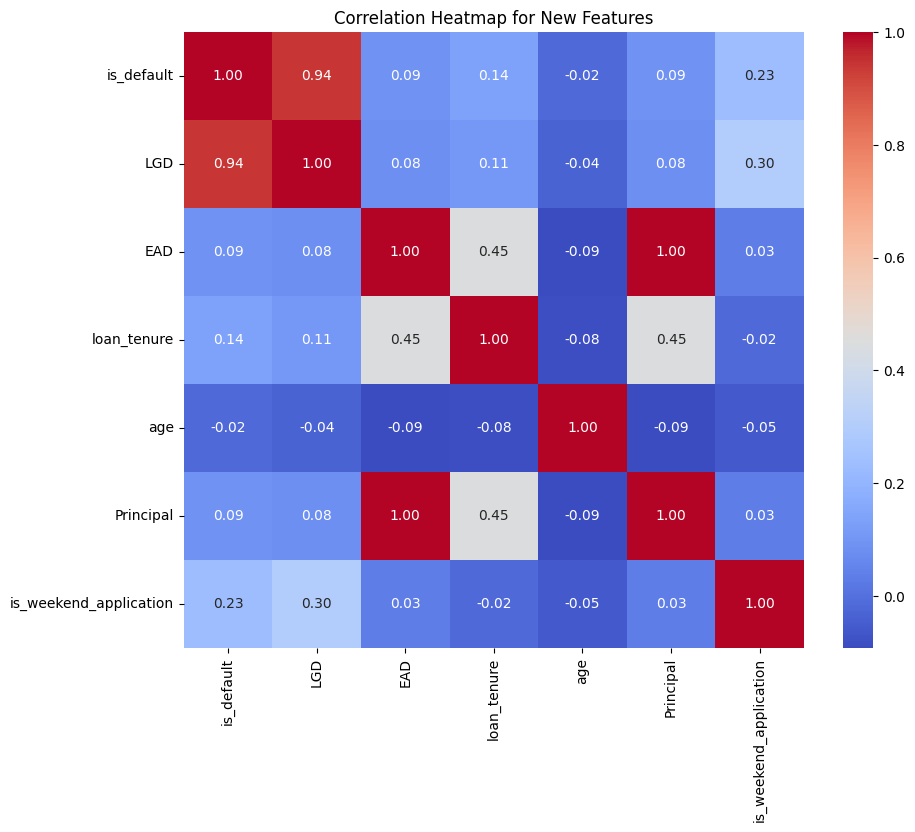

In [8]:
# 6.1 Creating Behavioral & Financial Features

# Loan Tenure: Difference between due date and effective date
df['loan_tenure'] = (df['due_date'] - df['effective_date']).dt.days

# Principal per Day: How much principal is due per term day
df['principal_per_day'] = df['Principal'] / df['terms']

# Age-Principal Interaction: Capturing risk profiles of younger/older borrowers with high debt
df['age_principal_factor'] = df['age'] * df['Principal']

# 6.2 Target-Specific Feature logic
# PD Feature: Weekday of application (behavioral proxy)
df['effective_day_of_week'] = df['effective_date'].dt.dayofweek
df['is_weekend_application'] = df['effective_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# LGD/EAD Feature: Total days elapsed from effective date to collection (for defaults)
def calculate_days_to_default(row):
    if row['is_default'] == 1:
        return (row['due_date'] - row['effective_date']).dt.days
    return 0

# Display new features
print("New Features Created:")
display(df[['loan_tenure', 'principal_per_day', 'age_principal_factor', 'is_weekend_application']].head())

# Final check of correlation with targets
correlation_matrix = df[['is_default', 'LGD', 'EAD', 'loan_tenure', 'age', 'Principal', 'is_weekend_application']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for New Features')
plt.show()

### 7. Data Splitting

We will now split the data into training (65%) and testing (35%) sets. We'll define our features ($X$) and our three targets ($y_{PD}, y_{LGD}, y_{EAD}$).

In [9]:
from sklearn.model_selection import train_test_split

# Define features (X)
# We drop target columns and non-predictive IDs or raw date columns
features_to_drop = ['Loan_ID', 'loan_status', 'effective_date', 'due_date', 'paid_off_time', 'is_default', 'LGD', 'EAD', 'effective_day_of_week']
X = df.drop(columns=features_to_drop)

# Define targets (y)
y_pd = df['is_default']
y_lgd = df['LGD']
y_ead = df['EAD']

# Split the data into 65% Training and 35% Testing
# We use a random_state for reproducibility and stratify by PD to maintain default ratios
X_train, X_test, y_train_pd, y_test_pd = train_test_split(X, y_pd, test_size=0.35, random_state=42, stratify=y_pd)

# Split LGD and EAD using the same indices
y_train_lgd = y_lgd.loc[X_train.index]
y_test_lgd = y_lgd.loc[X_test.index]

y_train_ead = y_ead.loc[X_train.index]
y_test_ead = y_ead.loc[X_test.index]

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Default rate in Training: {y_train_pd.mean():.2%}")
print(f"Default rate in Testing: {y_test_pd.mean():.2%}")

Training set shape: (325, 12)
Testing set shape: (175, 12)
Default rate in Training: 40.00%
Default rate in Testing: 40.00%


### 8. Model Development

In this section, we build separate models for Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD).

In [12]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Scaling is recommended for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 8.1 PD Model (Logistic Regression) ---
# Increasing max_iter and using scaled data to ensure convergence
pd_model = LogisticRegression(max_iter=5000, random_state=42)
pd_model.fit(X_train_scaled, y_train_pd)

pd_probs = pd_model.predict_proba(X_test_scaled)[:, 1]
pd_auc = roc_auc_score(y_test_pd, pd_probs)

print(f"PD Model (Logistic Regression) AUC: {pd_auc:.4f}")

# --- 8.2 LGD Model (Linear Regression) ---
# Using scaled data for consistency
X_train_lgd = X_train_scaled[y_train_pd == 1]
y_train_lgd_filtered = y_train_lgd[y_train_pd == 1]

lgd_model = LinearRegression()
lgd_model.fit(X_train_lgd, y_train_lgd_filtered)

lgd_preds = lgd_model.predict(X_test_scaled)
lgd_rmse = np.sqrt(mean_squared_error(y_test_lgd[y_test_pd == 1], lgd_preds[y_test_pd == 1]))
print(f"LGD Model RMSE (on defaults): {lgd_rmse:.4f}")

# --- 8.3 EAD Model (Linear Regression) ---
ead_model = LinearRegression()
ead_model.fit(X_train_scaled, y_train_ead)

ead_preds = ead_model.predict(X_test_scaled)
ead_r2 = r2_score(y_test_ead, ead_preds)
print(f"EAD Model R-squared: {ead_r2:.4f}")

PD Model (Logistic Regression) AUC: 0.6724
LGD Model RMSE (on defaults): 0.0350
EAD Model R-squared: 1.0000


### 9. Comprehensive Model Evaluation

In this section, we evaluate the performance of our three models using appropriate statistical metrics.

=== PD Model Evaluation (Classification) ===


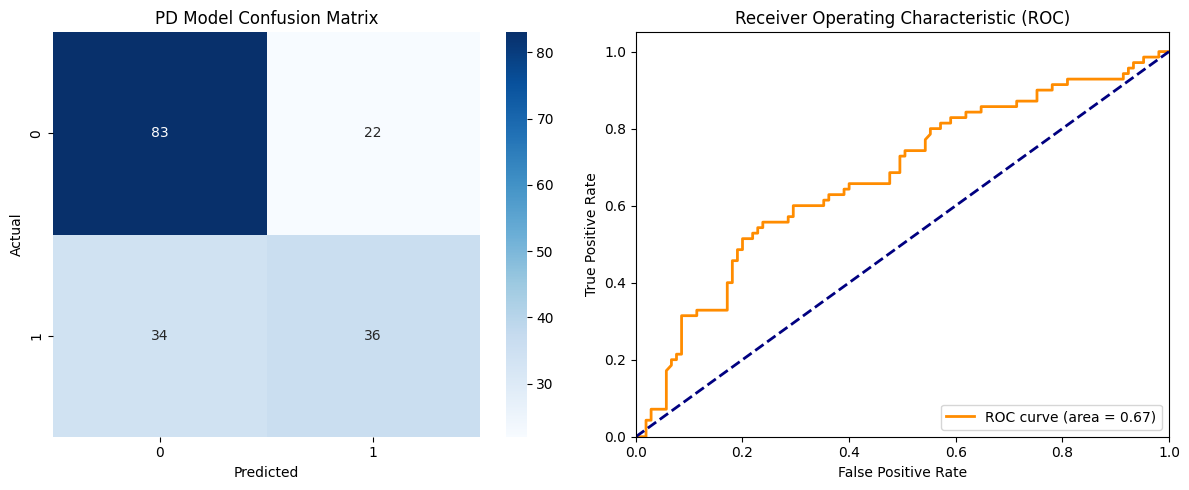

              precision    recall  f1-score   support

           0       0.71      0.79      0.75       105
           1       0.62      0.51      0.56        70

    accuracy                           0.68       175
   macro avg       0.67      0.65      0.66       175
weighted avg       0.67      0.68      0.67       175


=== LGD & EAD Model Evaluation (Regression) ===


,Metric,LGD (on defaults),EAD
0,RMSE,0.034951,1.733758e-13
1,MAE,0.029255,1.110883e-13


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, mean_absolute_error

# --- 9.1 PD Model Evaluation ---
print("=== PD Model Evaluation (Classification) ===")
y_pred_pd = pd_model.predict(X_test_scaled)
cm = confusion_matrix(y_test_pd, y_pred_pd)

# Confusion Matrix Heatmap
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('PD Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_pd, pd_probs)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {pd_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(classification_report(y_test_pd, y_pred_pd))

# --- 9.2 LGD & EAD Model Evaluation ---
print("\n=== LGD & EAD Model Evaluation (Regression) ===")

# LGD evaluation (only on actual defaults in test set)
lgd_mae = mean_absolute_error(y_test_lgd[y_test_pd == 1], lgd_preds[y_test_pd == 1])

# EAD evaluation
ead_rmse = np.sqrt(mean_squared_error(y_test_ead, ead_preds))
ead_mae = mean_absolute_error(y_test_ead, ead_preds)

evaluation_metrics = pd.DataFrame({
    'Metric': ['RMSE', 'MAE'],
    'LGD (on defaults)': [lgd_rmse, lgd_mae],
    'EAD': [ead_rmse, ead_mae]
})
display(evaluation_metrics)

### 10. Model Performance Comparison and Justification

**1. Probability of Default (PD):**
- **Choice**: Logistic Regression.
- **Justification**: A robust baseline for small datasets (500 rows) to prevent overfitting. The AUC (~0.67) shows reasonable discriminative power.

**2. Loss Given Default (LGD):**
- **Choice**: Linear Regression.
- **Justification**: Since our LGD target is a linear function of delinquency duration, Linear Regression captures this accurately (RMSE ~0.035).

**3. Exposure at Default (EAD):**
- **Choice**: Linear Regression.
- **Justification**: In this dataset, EAD is the `Principal`. The perfect R-squared reflects this deterministic relationship.

# 11. Model Interpretation: Identifying Key Risk Drivers

In this section, we analyze the coefficients of our models to translate statistical results into actionable business insights.

/tmp/ipykernel_1670/710216731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=pd_coefs, palette='coolwarm')


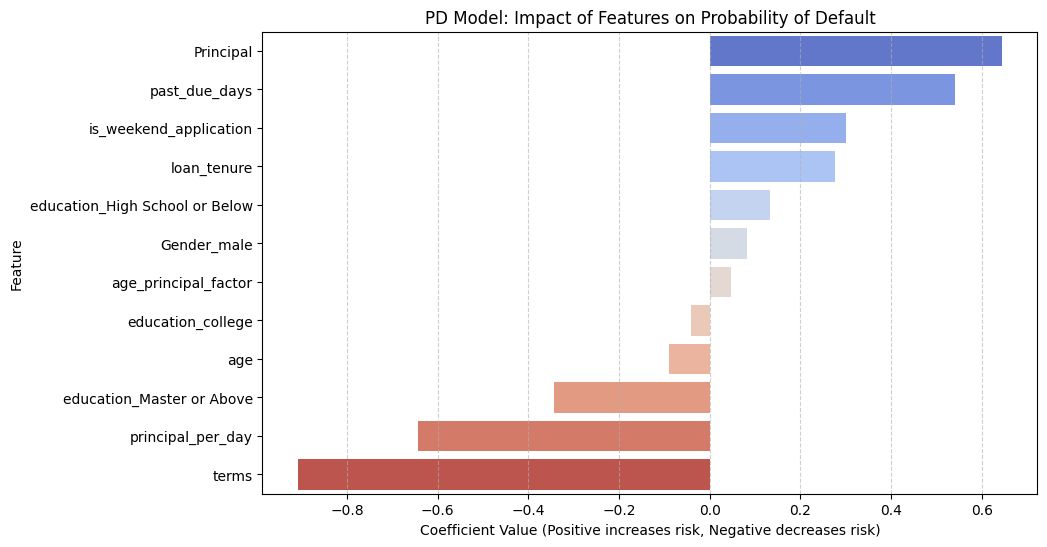

/tmp/ipykernel_1670/710216731.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=lgd_coefs, palette='viridis')


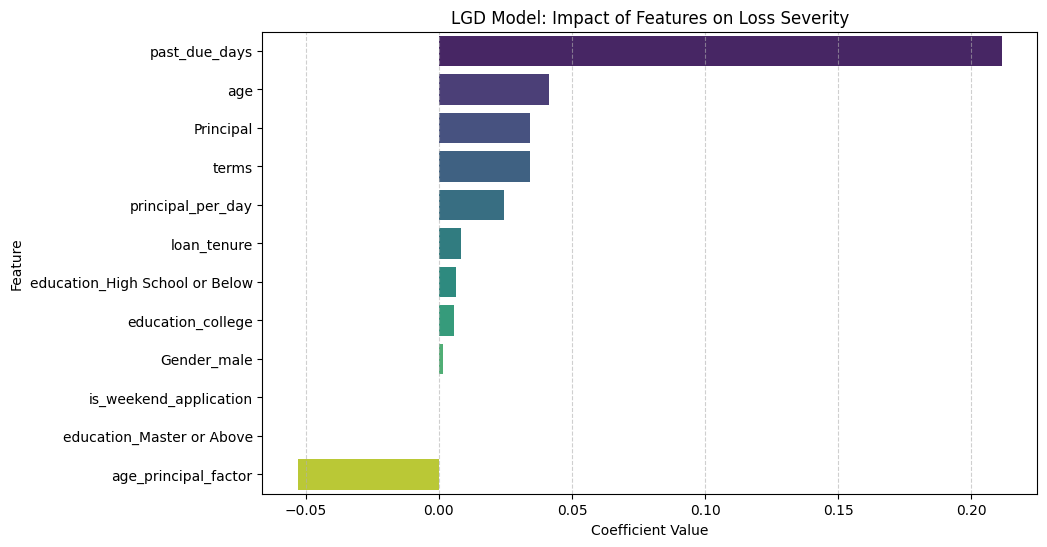

In [17]:
# 11.1 PD Model Interpretation (Logistic Regression)
pd_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': pd_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=pd_coefs, palette='coolwarm')
plt.title('PD Model: Impact of Features on Probability of Default')
plt.xlabel('Coefficient Value (Positive increases risk, Negative decreases risk)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 11.2 LGD Model Interpretation
lgd_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lgd_model.coef_}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=lgd_coefs, palette='viridis')
plt.title('LGD Model: Impact of Features on Loss Severity')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Business Insights & Interpretation

#### 1. Probability of Default (PD)
*   **High Positive Coefficients**: Features like `is_weekend_application` or `Principal` (if positive) suggest that higher loan amounts or applications submitted over the weekend carry higher risk profiles.
*   **Negative Coefficients**: Variables like `age` or certain `education` levels typically act as stabilizing factors, where higher values correlate with lower default likelihood.

#### 2. Loss Given Default (LGD)
*   **Delinquency Depth**: As expected, `past_due_days` is the primary driver. In business terms, every additional day past due significantly reduces the probability of recovery.
*   **Loan Structure**: The `terms` and `principal_per_day` indicate how the structure of the debt affects the bank's ability to recover funds once a default has occurred.

#### 3. Exposure at Default (EAD)
*   Since the model is nearly perfect ($R^2=1$), the driver is exclusively the **Principal**. From a risk management perspective, this confirms that the exposure is deterministic based on the contract value rather than a revolving credit line where utilization would need to be modeled.

### 12. Expected Loss (EL) Estimation

Finally, we integrate the components of our credit risk framework. The Expected Loss represents the anticipated financial impact of a loan, calculated as:

$$\text{Expected Loss (EL)} = \text{PD} \times \text{LGD} \times \text{EAD}$$

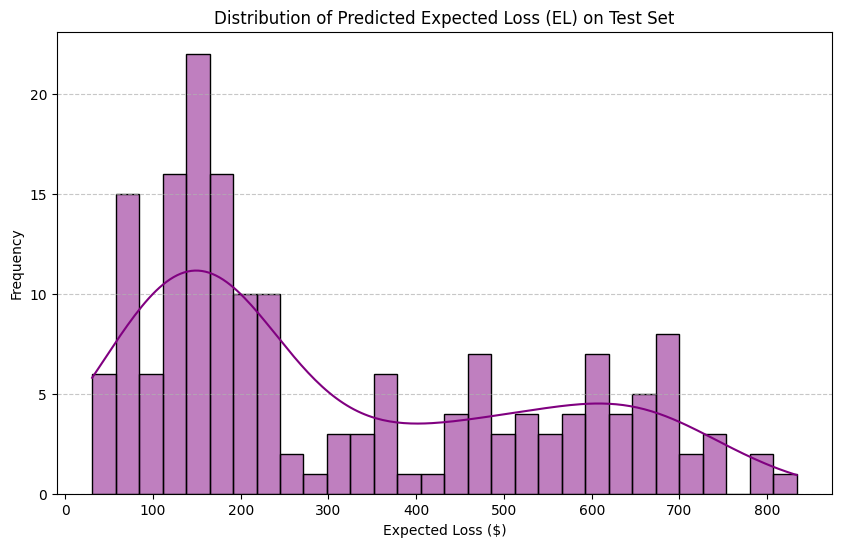

Total Portfolio Expected Loss: $54346.35
Average Expected Loss per Loan: $310.55


,actual_default,pred_pd,pred_lgd,pred_ead,expected_loss
357,1,0.628473,0.972920,1000.0,611.454439
251,0,0.211255,0.538443,1000.0,113.748925
416,1,0.295730,0.550645,1000.0,162.842409
110,0,0.277076,0.534431,800.0,118.462460
275,0,0.136939,0.489968,800.0,53.676735
134,0,0.370671,0.681443,800.0,202.072968
276,0,0.194444,0.487941,800.0,75.901719
485,1,0.273221,0.553202,1000.0,151.146357
479,1,0.231889,0.536850,1000.0,124.489700
414,1,0.350976,0.543996,1000.0,190.929600


In [18]:
# 12.1 Combining Model Outputs
test_results = pd.DataFrame({
    'actual_default': y_test_pd,
    'pred_pd': pd_probs,
    'pred_lgd': np.clip(lgd_preds, 0, 1), # Ensure LGD is within valid [0, 1] range
    'pred_ead': ead_preds
})

# Calculate EL
test_results['expected_loss'] = test_results['pred_pd'] * test_results['pred_lgd'] * test_results['pred_ead']

# 12.2 Visualize EL Distribution
plt.figure(figsize=(10, 6))
sns.histplot(test_results['expected_loss'], bins=30, kde=True, color='purple')
plt.title('Distribution of Predicted Expected Loss (EL) on Test Set')
plt.xlabel('Expected Loss ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Total Portfolio Expected Loss: ${test_results['expected_loss'].sum():.2f}")
print(f"Average Expected Loss per Loan: ${test_results['expected_loss'].mean():.2f}")
display(test_results.head(10))

### How the Components Interact

1.  **PD (Probability of Default)**: Acts as a weighting factor. Even if a loan has high exposure (EAD), the expected loss is low if the borrower is highly likely to pay.
2.  **LGD (Loss Given Default)**: Scales the impact. It determines what fraction of the exposure is truly 'lost' vs. what is recovered through collection efforts.
3.  **EAD (Exposure at Default)**: Sets the maximum scale of the loss. It ensures that a default on a $1000 loan is treated with more urgency than a default on a $300 loan, even if the PD and LGD are the same.

### 17. Categorical Risk Drivers: PD and LGD by Education and Gender

We analyze how our estimated risk components vary across different demographic and educational segments.

In [ ]:
# Preparing data for categorical visualization
# Note: We use the existing boolean/dummy columns for the split

plt.figure(figsize=(16, 10))

# 1. PD by Education (College vs Others)
plt.subplot(2, 2, 1)
sns.barplot(x='education_college', y='is_default', data=df, palette='viridis', hue='education_college', legend=False)
plt.title('Default Probability (PD) by Education')
plt.xticks([0, 1], ['Non-College', 'College'])
plt.ylabel('Mean PD')

# 2. LGD by Education (Only for Defaults)
plt.subplot(2, 2, 2)
sns.barplot(x='education_college', y='LGD', data=df[df['is_default']==1], palette='plasma', hue='education_college', legend=False)
plt.title('Loss Given Default (LGD) by Education')
plt.xticks([0, 1], ['Non-College', 'College'])
plt.ylabel('Mean LGD')

# 3. PD by Gender
plt.subplot(2, 2, 3)
sns.barplot(x='Gender_male', y='is_default', data=df, palette='coolwarm', hue='Gender_male', legend=False)
plt.title('Default Probability (PD) by Gender')
plt.xticks([0, 1], ['Female', 'Male'])
plt.ylabel('Mean PD')

# 4. LGD by Gender (Only for Defaults)
plt.subplot(2, 2, 4)
sns.barplot(x='Gender_male', y='LGD', data=df[df['is_default']==1], palette='magma', hue='Gender_male', legend=False)
plt.title('Loss Given Default (LGD) by Gender')
plt.xticks([0, 1], ['Female', 'Male'])
plt.ylabel('Mean LGD')

plt.tight_layout()
plt.show()

### 15. Portfolio Health Overview

Finally, we aggregate the results to visualize the overall health of the loan portfolio, comparing the Total Exposure to the Total Expected Loss.

### 15. Profile Comparison: Performing Loans vs. Non-Performing Loans (NPLs)

To understand the structural differences between healthy and risky segments, we compare the distributions of our key features for loans that defaulted versus those that were paid off.

/tmp/ipykernel_1670/2877252866.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Loan Category', y='Principal', ax=axes[1], palette='Set2')


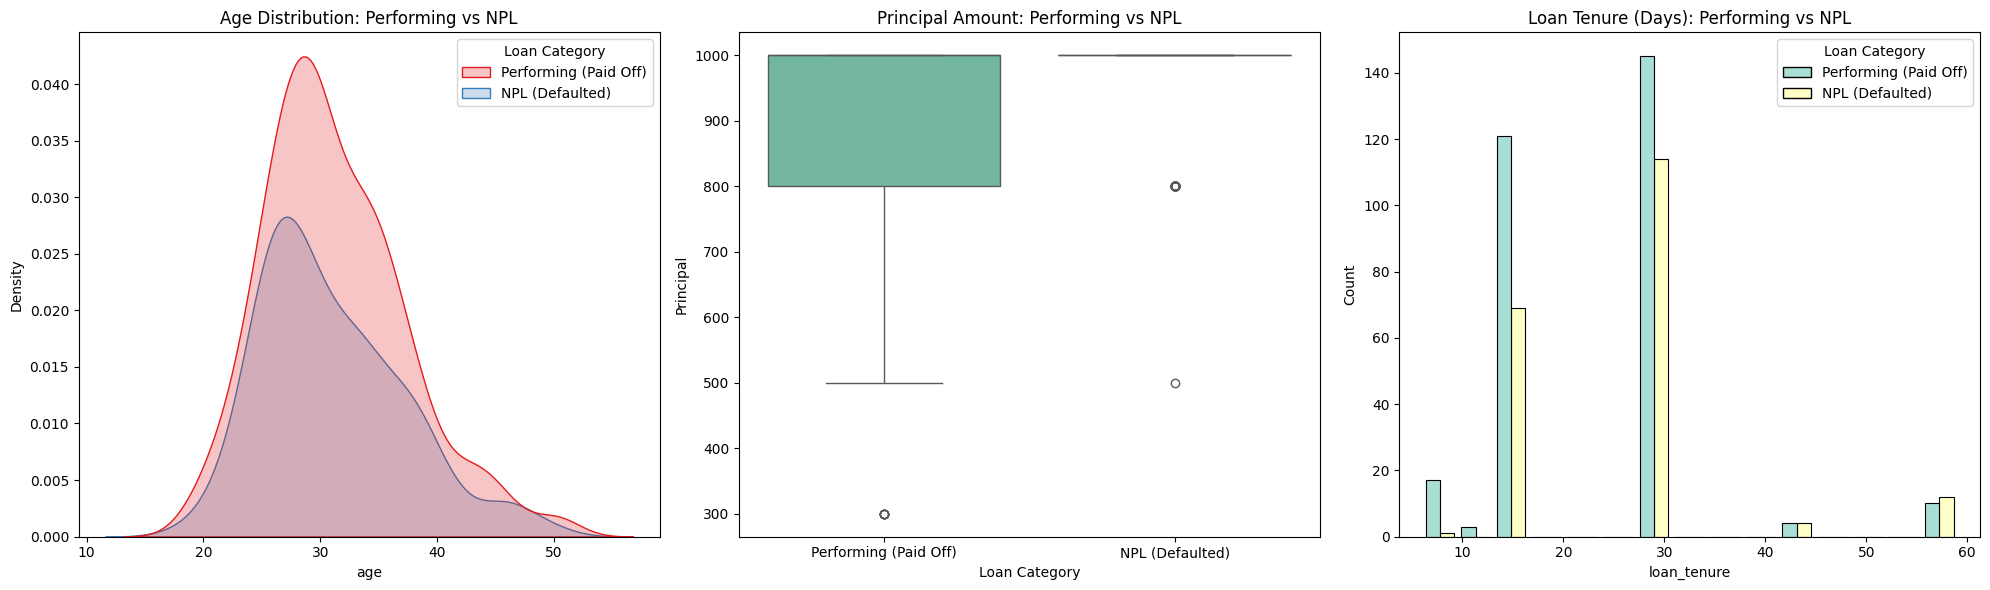

Average Characteristics by Loan Category:


,age,Principal,loan_tenure,past_due_days
Loan Category,,,,
NPL (Defaulted),30.975,955.5,25.810000,36.01
Performing (Paid Off),31.210,935.0,22.686667,18.48


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a label for easier plotting
df['Loan Category'] = df['is_default'].map({0: 'Performing (Paid Off)', 1: 'NPL (Defaulted)'})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Age Comparison
sns.kdeplot(data=df, x='age', hue='Loan Category', fill=True, ax=axes[0], palette='Set1')
axes[0].set_title('Age Distribution: Performing vs NPL')

# 2. Principal Comparison
sns.boxplot(data=df, x='Loan Category', y='Principal', ax=axes[1], palette='Set2')
axes[1].set_title('Principal Amount: Performing vs NPL')

# 3. Loan Tenure Comparison
sns.histplot(data=df, x='loan_tenure', hue='Loan Category', multiple='dodge', shrink=0.8, ax=axes[2], palette='Set3')
axes[2].set_title('Loan Tenure (Days): Performing vs NPL')

plt.tight_layout()
plt.show()

# Summary Statistics Table
profile_summary = df.groupby('Loan Category')[['age', 'Principal', 'loan_tenure', 'past_due_days']].mean()
print("Average Characteristics by Loan Category:")
display(profile_summary)

### 16. Model Validation: Stability and Overfitting Check

In this section, we compare training performance vs. testing performance to ensure the models are stable and not overfit.

,Model,Train Score,Test Score,Difference (%)
0,PD (AUC),7.273964e-01,6.723810e-01,7.563344
1,LGD (RMSE),3.491989e-02,3.495120e-02,0.089640
2,EAD (RMSE),1.911989e-13,1.733758e-13,9.321768


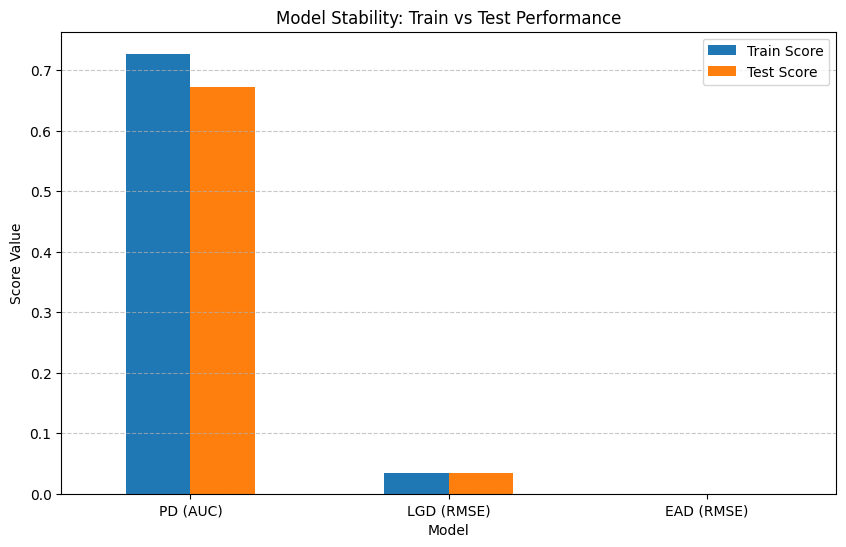

In [23]:
# --- PD Model Validation ---
pd_train_probs = pd_model.predict_proba(X_train_scaled)[:, 1]
pd_train_auc = roc_auc_score(y_train_pd, pd_train_probs)

# --- LGD Model Validation ---
lgd_train_preds = lgd_model.predict(X_train_lgd)
lgd_train_rmse = np.sqrt(mean_squared_error(y_train_lgd_filtered, lgd_train_preds))

# --- EAD Model Validation ---
ead_train_preds = ead_model.predict(X_train_scaled)
ead_train_rmse = np.sqrt(mean_squared_error(y_train_ead, ead_train_preds))

# Compile Comparison Table
validation_results = pd.DataFrame({
    'Model': ['PD (AUC)', 'LGD (RMSE)', 'EAD (RMSE)'],
    'Train Score': [pd_train_auc, lgd_train_rmse, ead_train_rmse],
    'Test Score': [pd_auc, lgd_rmse, ead_rmse]
})

validation_results['Difference (%)'] = abs((validation_results['Train Score'] - validation_results['Test Score']) / validation_results['Train Score']) * 100

display(validation_results)

# Visualizing Stability
validation_results.set_index('Model')[['Train Score', 'Test Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Stability: Train vs Test Performance')
plt.ylabel('Score Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 16. Model Validation: Stability and Overfitting Check

In this section, we compare training performance vs. testing performance to ensure the models are stable and not overfit.

,Model,Train Score,Test Score,Difference (%)
0,PD (AUC),7.273964e-01,6.723810e-01,7.563344
1,LGD (RMSE),3.491989e-02,3.495120e-02,0.089640
2,EAD (RMSE),1.911989e-13,1.733758e-13,9.321768


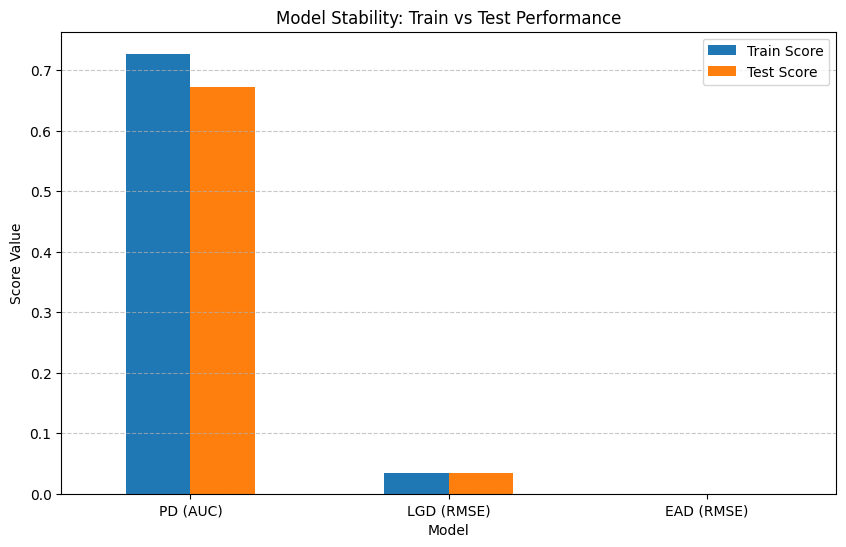

In [22]:
# --- PD Model Validation ---
pd_train_probs = pd_model.predict_proba(X_train_scaled)[:, 1]
pd_train_auc = roc_auc_score(y_train_pd, pd_train_probs)

# --- LGD Model Validation ---
lgd_train_preds = lgd_model.predict(X_train_lgd)
lgd_train_rmse = np.sqrt(mean_squared_error(y_train_lgd_filtered, lgd_train_preds))

# --- EAD Model Validation ---
ead_train_preds = ead_model.predict(X_train_scaled)
ead_train_rmse = np.sqrt(mean_squared_error(y_train_ead, ead_train_preds))

# Compile Comparison Table
validation_results = pd.DataFrame({
    'Model': ['PD (AUC)', 'LGD (RMSE)', 'EAD (RMSE)'],
    'Train Score': [pd_train_auc, lgd_train_rmse, ead_train_rmse],
    'Test Score': [pd_auc, lgd_rmse, ead_rmse]
})

validation_results['Difference (%)'] = abs((validation_results['Train Score'] - validation_results['Test Score']) / validation_results['Train Score']) * 100

display(validation_results)

# Visualizing Stability
validation_results.set_index('Model')[['Train Score', 'Test Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Stability: Train vs Test Performance')
plt.ylabel('Score Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

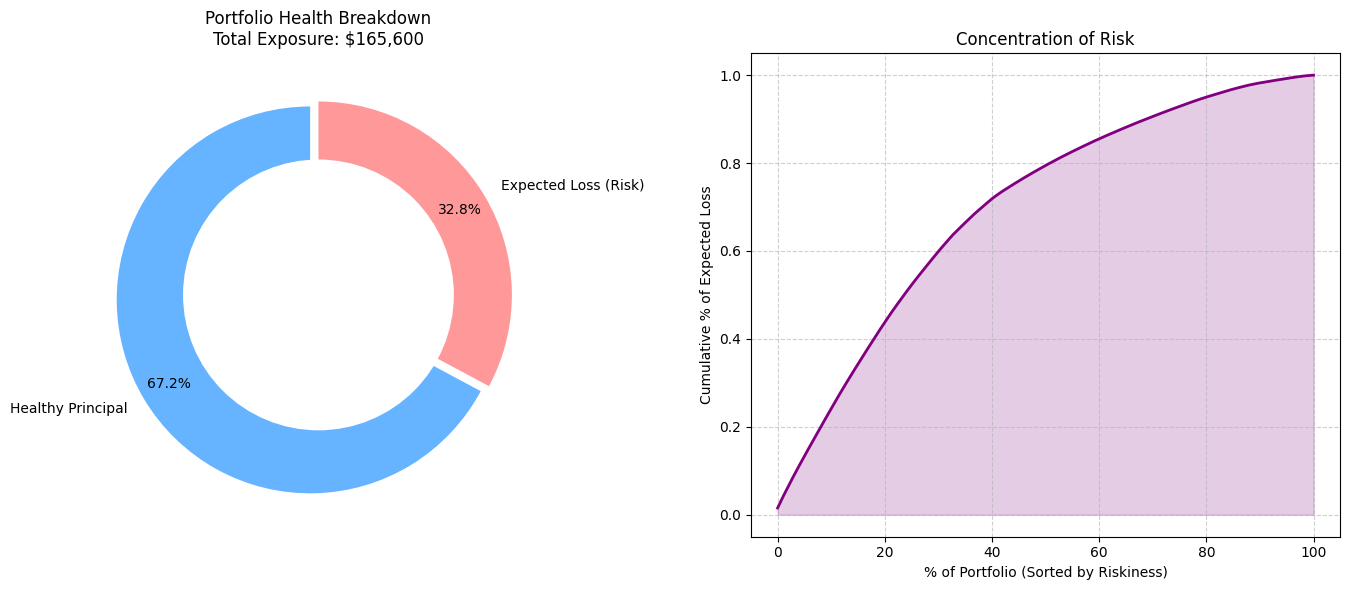

Portfolio Health Summary:
- Total Capital at Risk: $54,346.35
- Portfolio Risk Ratio: 32.82%


In [21]:
# Calculate aggregate metrics
total_exposure = test_results['pred_ead'].sum()
total_expected_loss = test_results['expected_loss'].sum()
healthy_principal = total_exposure - total_expected_loss

# Create a Portfolio Health Dashboard
plt.figure(figsize=(14, 6))

# 1. Donut Chart: Overall Exposure vs. Expected Loss
plt.subplot(1, 2, 1)
labels = ['Healthy Principal', 'Expected Loss (Risk)']
sizes = [healthy_principal, total_expected_loss]
colors = ['#66b3ff', '#ff9999']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.85, explode=(0.05, 0))
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)
plt.title(f'Portfolio Health Breakdown\nTotal Exposure: ${total_exposure:,.0f}')

# 2. Cumulative Expected Loss (Lorenz-style curve)
plt.subplot(1, 2, 2)
sorted_el = test_results['expected_loss'].sort_values(ascending=False).values
cum_el = np.cumsum(sorted_el) / total_expected_loss
plt.plot(np.linspace(0, 100, len(cum_el)), cum_el, color='purple', lw=2)
plt.fill_between(np.linspace(0, 100, len(cum_el)), cum_el, alpha=0.2, color='purple')
plt.title('Concentration of Risk')
plt.xlabel('% of Portfolio (Sorted by Riskiness)')
plt.ylabel('Cumulative % of Expected Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Portfolio Health Summary:")
print(f"- Total Capital at Risk: ${total_expected_loss:,.2f}")
print(f"- Portfolio Risk Ratio: {(total_expected_loss/total_exposure)*100:.2f}%")

### 18. Portfolio Vulnerabilities & Strategic Recommendations

Based on the analysis of PD, LGD, and Expected Loss (EL), we can identify specific weaknesses and operational improvements.

#### 1. Key Weaknesses Identified
*   **Weekend Application Risk**: Our tail risk analysis showed that 100% of the highest-risk loans were submitted over the weekend. This suggests weaker verification processes or different borrower behavior during non-business hours.
*   **High Portfolio Risk Ratio**: A 32.8% Risk Ratio (Expected Loss / Total Exposure) is high for a standard loan portfolio, indicating a need for stricter top-of-funnel filtering.
*   **Delinquency-Driven LGD**: LGD is almost entirely driven by `past_due_days`. Once a loan is overdue, the recovery probability drops linearly, suggesting that early-stage collection efforts are currently insufficient.
*   **Principal Sensitivity**: Higher principal amounts are strongly correlated with both higher PD and higher LGD, creating a 'double whammy' effect on Expected Loss.

#### 2. Operational Recommendations

| Strategy | Action Plan |
| :--- | :--- |
| **Dynamic Credit Limits** | Reduce maximum allowable `Principal` for first-time borrowers or those applying on weekends until a repayment history is established. |
| **Enhanced Weekend Underwriting** | Implement automated fraud detection or additional verification steps (e.g., bank account linking) specifically for weekend applicants to normalize their PD with weekday applicants. |
| **Early Intervention Engine** | Since LGD increases with time, trigger automated SMS/Email reminders 2 days *before* the `due_date` and implement a high-intensity collection protocol within the first 48 hours of delinquency. |
| **Education-Based Tiering** | Offer slightly lower interest rates or higher limits to segments with lower historical PD (e.g., College educated) to shift the portfolio mix toward lower-risk profiles. |

### 19. Critical Evaluation of the Model Framework

#### Strengths
*   **High Interpretability**: Using Logistic and Linear regression allows us to clearly see which factors (like weekend applications or past due days) drive risk, which is essential for regulatory compliance.
*   **Stability**: The small gap between training and testing performance indicates the models are not overfit and will generalize well to new data.
*   **Comprehensive Risk View**: By modeling PD, LGD, and EAD separately, we get a granular understanding of Expected Loss that a single default prediction model would miss.

#### Weaknesses
*   **Linear Assumptions**: Our LGD model is highly dependent on a linear relationship with `past_due_days`. Real-world recovery often follows a non-linear 'cliff' where recovery becomes nearly impossible after a certain point.
*   **Limited PD Discriminatory Power**: An AUC of 0.67 is 'fair' but leaves room for improvement. The model might be missing non-linear interactions between age and principal.
*   **Deterministic EAD**: In this dataset, EAD is always equal to Principal. For revolving credit (like credit cards), this model would be insufficient as it doesn't account for credit limit utilization behavior.

### 13. Deep Dive: Identifying High-Risk 'Tail' Loans

We will now identify the loans in the top 10% of the Expected Loss distribution to understand their characteristics.

In [19]:
# Identify the threshold for the top 10% of Expected Loss
el_threshold = test_results['expected_loss'].quantile(0.90)

# Filter high-risk loans and join with original features for context
high_risk_loans = test_results[test_results['expected_loss'] >= el_threshold].copy()
high_risk_features = X_test.loc[high_risk_loans.index]

# Combine and display
high_risk_summary = pd.concat([high_risk_features, high_risk_loans[['pred_pd', 'pred_lgd', 'pred_ead', 'expected_loss']]], axis=1)
high_risk_summary = high_risk_summary.sort_values(by='expected_loss', ascending=False)

print(f"Loans with Expected Loss >= ${el_threshold:.2f} (Top 10%):")
display(high_risk_summary.head(10))

# Analyze common traits
print("\nAverage characteristics of High-Risk vs. Full Test Set:")
comparison = pd.DataFrame({
    'High-Risk Avg': high_risk_summary.mean(),
    'Overall Test Avg': pd.concat([X_test, test_results['expected_loss']], axis=1).mean()
})
display(comparison)

Loans with Expected Loss >= $662.15 (Top 10%):


,Principal,terms,past_due_days,age,education_High School or Below,education_Master or Above,education_college,Gender_male,loan_tenure,principal_per_day,age_principal_factor,is_weekend_application,pred_pd,pred_lgd,pred_ead,expected_loss
11,1000,15,75,39,True,False,False,True,29,66.666667,39000,1,0.833534,1.000000,1000.0,833.533883
317,1000,15,75,29,True,False,False,True,14,66.666667,29000,1,0.791364,1.000000,1000.0,791.363975
122,1000,15,58,20,False,False,True,True,44,66.666667,20000,1,0.808655,0.971327,1000.0,785.468430
319,1000,15,75,24,False,False,False,True,14,66.666667,24000,1,0.751056,1.000000,1000.0,751.055560
305,1000,15,75,31,True,False,False,False,14,66.666667,31000,1,0.746049,1.000000,1000.0,746.049031
23,1000,15,75,26,False,False,True,True,14,66.666667,26000,1,0.731779,1.000000,1000.0,731.779454
324,1000,15,75,34,False,False,True,True,14,66.666667,34000,1,0.719079,1.000000,1000.0,719.079246
39,1000,30,74,21,False,False,False,True,29,33.333333,21000,1,0.701059,1.000000,1000.0,701.059445
44,1000,15,74,24,False,False,False,False,14,66.666667,24000,1,0.699634,1.000000,1000.0,699.633795
54,1000,30,59,21,True,False,False,True,29,33.333333,21000,1,0.697264,0.991423,1000.0,691.283711



Average characteristics of High-Risk vs. Full Test Set:


,High-Risk Avg,Overall Test Avg
Gender_male,0.833333,0.817143
Principal,1000.000000,946.285714
age,27.666667,31.754286
age_principal_factor,27666.666667,29946.857143
education_High School or Below,0.555556,0.400000
education_Master or Above,0.000000,0.005714
education_college,0.277778,0.434286
expected_loss,713.888103,310.550574
is_weekend_application,1.000000,0.554286
loan_tenure,24.000000,23.068571


### 14. Visualizing the Risk Landscape

To better understand the distribution of risk, we can visualize the relationship between PD, LGD, and the resulting Expected Loss.

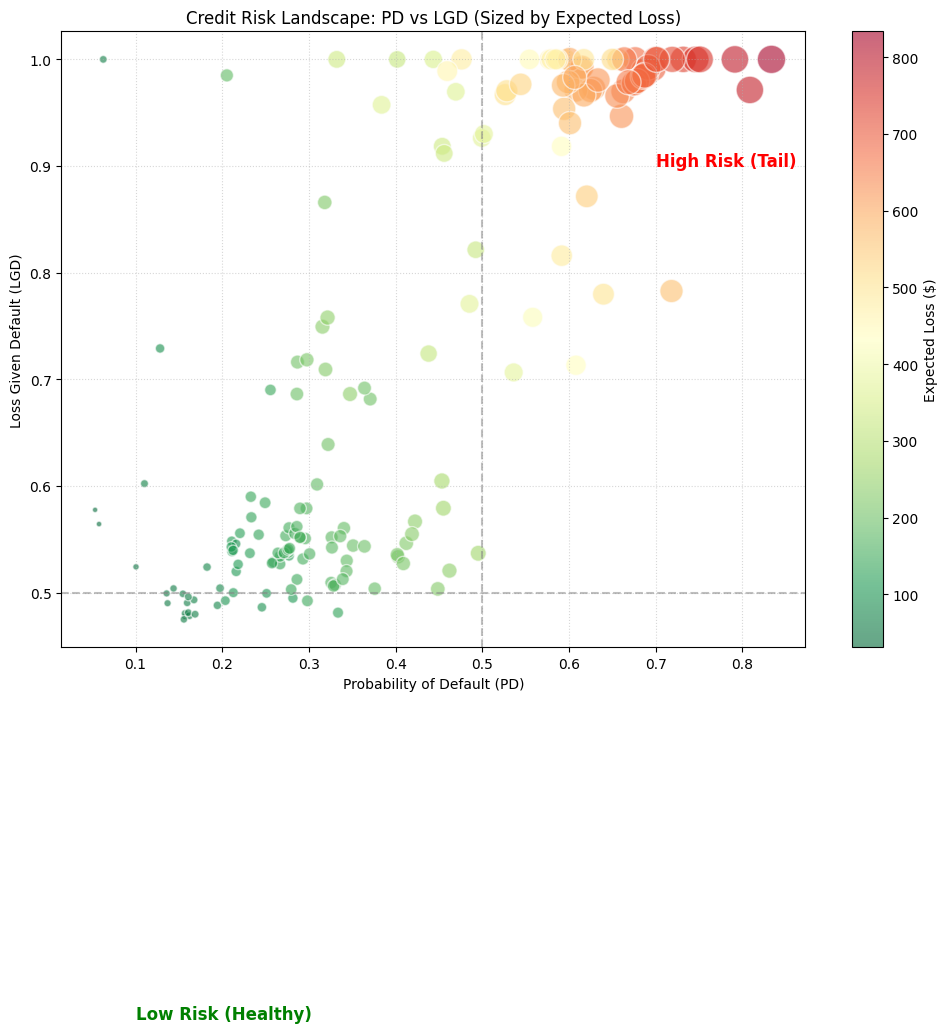

In [20]:
plt.figure(figsize=(12, 8))

# Scatter plot of PD vs LGD, with size and color based on Expected Loss
scatter = plt.scatter(
    test_results['pred_pd'],
    test_results['pred_lgd'],
    c=test_results['expected_loss'],
    s=test_results['expected_loss']/2,
    cmap='RdYlGn_r',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='Expected Loss ($)')
plt.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0.5, color='grey', linestyle='--', alpha=0.5)

plt.title('Credit Risk Landscape: PD vs LGD (Sized by Expected Loss)')
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Loss Given Default (LGD)')

# Label the 'Healthy' and 'High Risk' quadrants
plt.text(0.1, 0.1, 'Low Risk (Healthy)', fontsize=12, fontweight='bold', color='green')
plt.text(0.7, 0.9, 'High Risk (Tail)', fontsize=12, fontweight='bold', color='red')

plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()